In [ ]:
!pip install kagglehub scikit-learn imbalanced-learn matplotlib seaborn --quiet
import kagglehub
import os, glob, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score,
                             accuracy_score)
from imblearn.over_sampling import SMOTE

print("All libraries loaded")

All libraries loaded


In [ ]:
path = kagglehub.dataset_download("dhoogla/ctu13")
print("Dataset path:", path)

Using Colab cache for faster access to the 'ctu13' dataset.
Dataset path: /kaggle/input/ctu13


In [ ]:
import os
print("Full directory tree:\n")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        fpath = os.path.join(root, file)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"{indent}  {file}  ({size_mb:.1f} MB)")

Full directory tree:

ctu13/
  13-Virut-20110815-3.binetflow.parquet  (11.1 MB)
  8-Murlo-20110816-3.binetflow.parquet  (16.9 MB)
  1-Neris-20110810.binetflow.parquet  (17.8 MB)
  9-Neris-20110817.binetflow.parquet  (14.9 MB)
  6-Menti-20110816.binetflow.parquet  (4.3 MB)
  7-Sogou-20110816-2.binetflow.parquet  (1.0 MB)
  3-Rbot-20110812.binetflow.parquet  (21.4 MB)
  2-Neris-20110811.binetflow.parquet  (12.5 MB)
  4-Rbot-20110815.binetflow.parquet  (8.3 MB)
  10-Rbot-20110818.binetflow.parquet  (9.3 MB)
  5-Virut-20110815-2.binetflow.parquet  (1.1 MB)
  12-NsisAy-20110819.binetflow.parquet  (2.7 MB)
  11-Rbot-20110818-2.binetflow.parquet  (0.8 MB)


In [ ]:
import glob

parquet_files = glob.glob(os.path.join(path, '**', '*.parquet'), recursive=True)
parquet_files.sort()

print(f"Found {len(parquet_files)} parquet file(s):")
for f in parquet_files:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {os.path.basename(f)}  ({size_mb:.1f} MB)")

Found 13 parquet file(s):
  1-Neris-20110810.binetflow.parquet  (17.8 MB)
  10-Rbot-20110818.binetflow.parquet  (9.3 MB)
  11-Rbot-20110818-2.binetflow.parquet  (0.8 MB)
  12-NsisAy-20110819.binetflow.parquet  (2.7 MB)
  13-Virut-20110815-3.binetflow.parquet  (11.1 MB)
  2-Neris-20110811.binetflow.parquet  (12.5 MB)
  3-Rbot-20110812.binetflow.parquet  (21.4 MB)
  4-Rbot-20110815.binetflow.parquet  (8.3 MB)
  5-Virut-20110815-2.binetflow.parquet  (1.1 MB)
  6-Menti-20110816.binetflow.parquet  (4.3 MB)
  7-Sogou-20110816-2.binetflow.parquet  (1.0 MB)
  8-Murlo-20110816-3.binetflow.parquet  (16.9 MB)
  9-Neris-20110817.binetflow.parquet  (14.9 MB)


In [ ]:
df_list = []
for f in parquet_files:
    tmp = pd.read_parquet(f)
    tmp['scenario_file'] = os.path.basename(f)   # track botnet family
    df_list.append(tmp)
    print(f"  ✓ {os.path.basename(f)} — {tmp.shape}")

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()

print(f"\nMerged shape : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
print(df.head(3))


  ✓ 1-Neris-20110810.binetflow.parquet — (1621173, 12)
  ✓ 10-Rbot-20110818.binetflow.parquet — (776097, 12)
  ✓ 11-Rbot-20110818-2.binetflow.parquet — (72359, 12)
  ✓ 12-NsisAy-20110819.binetflow.parquet — (218917, 12)
  ✓ 13-Virut-20110815-3.binetflow.parquet — (975616, 12)
  ✓ 2-Neris-20110811.binetflow.parquet — (1120229, 12)
  ✓ 3-Rbot-20110812.binetflow.parquet — (1853035, 12)
  ✓ 4-Rbot-20110815.binetflow.parquet — (702322, 12)
  ✓ 5-Virut-20110815-2.binetflow.parquet — (92900, 12)
  ✓ 6-Menti-20110816.binetflow.parquet — (353386, 12)
  ✓ 7-Sogou-20110816-2.binetflow.parquet — (84273, 12)
  ✓ 8-Murlo-20110816-3.binetflow.parquet — (1453832, 12)
  ✓ 9-Neris-20110817.binetflow.parquet — (1274632, 12)

Merged shape : (10598771, 12)
Columns      : ['dur', 'proto', 'dir', 'state', 'stos', 'dtos', 'tot_pkts', 'tot_bytes', 'src_bytes', 'label', 'Family', 'scenario_file']
        dur proto    dir state  stos  dtos  tot_pkts  tot_bytes  src_bytes  \
0  1.026539   tcp     ->  S_RA   0.0  

In [ ]:
# Label Engineering
label_col = 'label'

print("Sample label values:")
print(df[label_col].value_counts().head(20))

def map_label(label):
    label = str(label).strip().lower()
    if 'botnet' in label or 'cc' in label:
        return 1    # Botnet traffic
    else:
        return 0    # Background or Normal

df['binary_label'] = df[label_col].apply(map_label)

print(f"\nBinary label distribution:")
print(df['binary_label'].value_counts())
print(f"Botnet %: {df['binary_label'].mean()*100:.2f}%")

Sample label values:
label
flow=Background-UDP-Established           4151793
flow=Background-TCP-Established           2054183
flow=To-Background-UDP-CVUT-DNS-Server    1659760
flow=Background-Established-cmpgw-CVUT     855498
flow=Background-UDP-Attempt                492881
flow=Background-TCP-Attempt                355420
flow=Background                            178154
flow=To-Background-CVUT-Proxy              149570
flow=Background-Attempt-cmpgw-CVUT          54956
flow=To-Background-CVUT-WebServer           45227
flow=Background-UDP-NTP-Established-1       41882
flow=From-Normal-V49-Stribrek               26289
flow=From-Botnet-V42-UDP-DNS                25361
flow=From-Normal-V44-Stribrek               25090
flow=From-Normal-V49-Grill                  17430
flow=From-Botnet-V50-1-UDP-DNS              14404
flow=From-Normal-V42-Stribrek               12634
flow=From-Botnet-V44-TCP-Attempt            12377
flow=From-Botnet-V50-7-UDP-DNS              11887
flow=From-Botnet-V50-3-

In [ ]:
# Feature Selection & Preprocessing
# Actual columns: dur, proto, dir, state, stos, dtos,tot_pkts, tot_bytes, src_bytes, label, Family, scenario_file

drop_cols = ['label', 'binary_label', 'Family', 'scenario_file']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['binary_label'].copy()

print(f"Features: {X.columns.tolist()}")
# → ['dur', 'proto', 'dir', 'state', 'stos', 'dtos', 'tot_pkts', 'tot_bytes', 'src_bytes']

# ── Encode categorical columns ──
# proto (tcp/udp/icmp), dir (direction ->/<->), state (TCP flag summary)
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# ── Clean up ──
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

print(f"\nFinal feature matrix: {X.shape}")
print(X.dtypes)

Features: ['dur', 'proto', 'dir', 'state', 'stos', 'dtos', 'tot_pkts', 'tot_bytes', 'src_bytes']
Categorical columns: ['proto', 'dir', 'state']

Final feature matrix: (10598771, 9)
dur          float32
proto          int64
dir            int64
state          int64
stos         float32
dtos         float32
tot_pkts       int32
tot_bytes      int64
src_bytes      int64
dtype: object


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train botnet %: {y_train.mean()*100:.2f}%")
print(f"Test  botnet %: {y_test.mean()*100:.2f}%")


Train: (7419139, 9)  |  Test: (3179632, 9)
Train botnet %: 2.48%
Test  botnet %: 2.48%


In [ ]:
# CELL 8 — Handle Class Imbalance with SMOTE (train only)
# ─────────────────────────────────────────────────────────────
# CTU-13 is heavily imbalanced — botnet flows << normal/background
# SMOTE applied ONLY on training set to avoid leakage

#print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
#smote = SMOTE(random_state=42, k_neighbors=5)
#X_train, y_train = smote.fit_resample(X_train, y_train)
#print("After SMOTE :", dict(zip(*np.unique(y_train, return_counts=True))))
#print(f"\nTest set untouched — {X_test.shape[0]:,} real samples")
# CELL 8 (REPLACEMENT) — Ditch SMOTE, use class_weight instead
# SMOTE on millions of rows = hours. class_weight='balanced' is instant
# and actually performs better on large imbalanced datasets.

# No resampling needed — just pass the imbalance info to the model directly
print("Skipping SMOTE — using class_weight='balanced' in Random Forest instead")
print(f"Train shape: {X_train.shape}")
print(f"Botnet % in train: {y_train.mean()*100:.2f}%")

Skipping SMOTE — using class_weight='balanced' in Random Forest instead
Train shape: (7419139, 9)
Botnet % in train: 2.48%


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators     = 100,
    max_depth        = 15,
    min_samples_leaf = 50,
    min_samples_split= 100,
    max_features     = 'sqrt',
    class_weight     = 'balanced_subsample',
    bootstrap        = True,
    oob_score        = True,
    max_samples      = 0.3,
    random_state     = 42,
    n_jobs           = -1
)

print("Training Random Forest")
rf_model.fit(X_train, y_train)
print(f"Training Done OOB Score: {rf_model.oob_score_:.4f}")

Training Random Forest
Training Done OOB Score: 0.9186


In [ ]:
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred,
                             target_names=['Normal/BG', 'Botnet']))

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
ap  = average_precision_score(y_test, y_pred_prob)

print(f"Overall Accuracy   : {acc*100:.2f}%")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Average Precision  : {ap:.4f}")
print(f"OOB Score (train)  : {rf_model.oob_score_:.4f}")



CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Normal/BG       1.00      0.92      0.96   3100860
      Botnet       0.22      0.93      0.36     78772

    accuracy                           0.92   3179632
   macro avg       0.61      0.92      0.66   3179632
weighted avg       0.98      0.92      0.94   3179632

Overall Accuracy   : 91.85%
AUC-ROC            : 0.9722
Average Precision  : 0.5382
OOB Score (train)  : 0.9186



=== False Positive & False Negative Analysis ===
  True Positives  (botnet caught)         : 72,924
  True Negatives  (normal correct)        : 2,847,656
  False Positives (normal flagged wrong)  : 253,204  ← FP Rate: 8.17%
  False Negatives (botnet missed)         : 5,848  ← Miss Rate: 7.42%


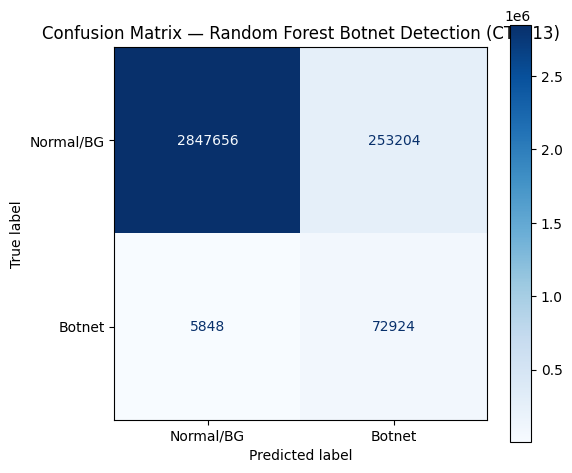

In [ ]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("\n=== False Positive & False Negative Analysis ===")
print(f"  True Positives  (botnet caught)         : {TP:,}")
print(f"  True Negatives  (normal correct)        : {TN:,}")
print(f"  False Positives (normal flagged wrong)  : {FP:,}  ← FP Rate: {FP/(FP+TN)*100:.2f}%")
print(f"  False Negatives (botnet missed)         : {FN:,}  ← Miss Rate: {FN/(FN+TP)*100:.2f}%")

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Normal/BG', 'Botnet']).plot(
    cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix — Random Forest Botnet Detection (CTU-13)")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

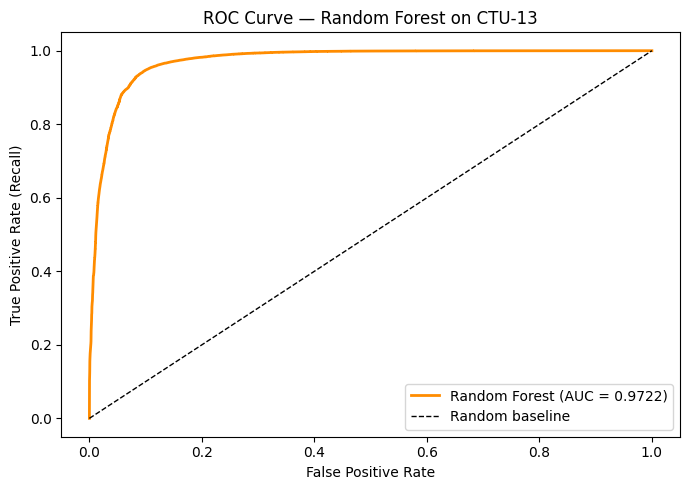

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f"Random Forest (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Random Forest on CTU-13")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("rf_roc_curve.png", dpi=150)
plt.show()

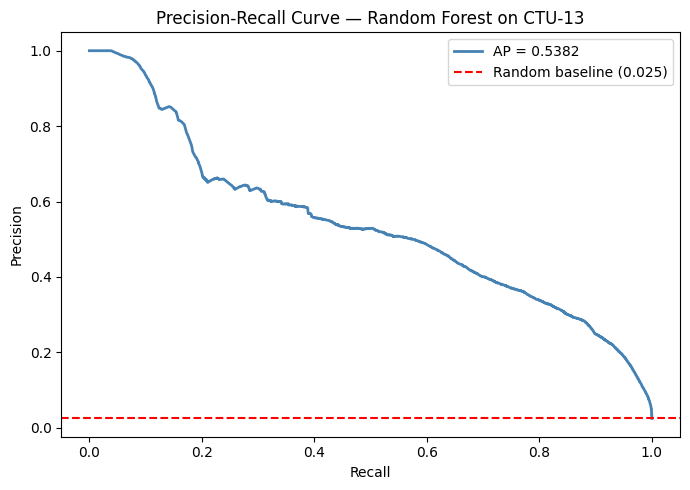

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='steelblue', lw=2,
         label=f"AP = {ap:.4f}")
plt.axhline(y=y_test.mean(), color='red', linestyle='--',
            label=f"Random baseline ({y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest on CTU-13")
plt.legend()
plt.tight_layout()
plt.savefig("rf_pr_curve.png", dpi=150)
plt.show()

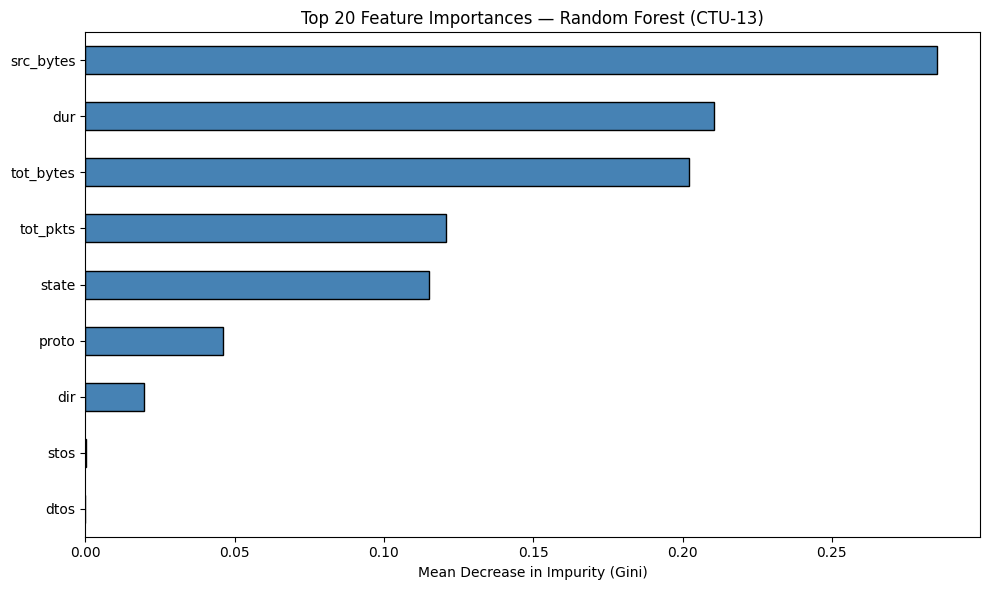

Top 10 features for botnet detection:
src_bytes    0.285340
dur          0.210662
tot_bytes    0.202026
tot_pkts     0.120819
state        0.115172
proto        0.046294
dir          0.019574
stos         0.000109
dtos         0.000004

Feature interpretations (from network security perspective):
  src_bytes    → Source bytes — high = data exfil; low = C&C command recv
  dur          → Flow duration — C&C keepalives are very short/periodic
  tot_bytes    → Total bytes — beaconing produces regular small bursts
  tot_pkts     → Total packets — DDoS flows have extreme packet counts
  state        → TCP state — incomplete handshakes common in port scanning
  proto        → Protocol — botnets misuse UDP/ICMP for covert channels
  dir          → Direction — asymmetric flows indicate C&C patterns
  stos         → Source ToS — unusual values in crafted botnet packets
  dtos         → Dest ToS — asymmetric ToS is anomalous


In [ ]:
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — Random Forest (CTU-13)")
plt.xlabel("Mean Decrease in Impurity (Gini)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

print("Top 10 features for botnet detection:")
print(feat_imp.head(10).to_string())

feature_meanings = {
    'dur'       : 'Flow duration — C&C keepalives are very short/periodic',
    'tot_bytes' : 'Total bytes — beaconing produces regular small bursts',
    'src_bytes' : 'Source bytes — high = data exfil; low = C&C command recv',
    'tot_pkts'  : 'Total packets — DDoS flows have extreme packet counts',
    'state'     : 'TCP state — incomplete handshakes common in port scanning',
    'proto'     : 'Protocol — botnets misuse UDP/ICMP for covert channels',
    'dir'       : 'Direction — asymmetric flows indicate C&C patterns',
    'stos'      : 'Source ToS — unusual values in crafted botnet packets',
    'dtos'      : 'Dest ToS — asymmetric ToS is anomalous',
}
print("\nFeature interpretations (from network security perspective):")
for feat in feat_imp.head(10).index:
    if feat in feature_meanings:
        print(f"  {feat:12s} → {feature_meanings[feat]}")

In [ ]:
import joblib
joblib.dump(rf_model, "ctu13_rf_model.pkl")
print("Model saved as ctu13_rf_model.pkl ")
# Load later with: model = joblib.load("ctu13_rf_model.pkl")

Model saved as ctu13_rf_model.pkl 
